In [12]:
import pandas as pd
import sqlite3

df = pd.read_csv("../day-5/shopping_trends-selected-columns.csv")

print(df.head())

   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)
0            1   55   Male         Blouse  Clothing                     53
1            2   19   Male        Sweater  Clothing                     64
2            3   50   Male          Jeans  Clothing                     73
3            4   21   Male        Sandals  Footwear                     90
4            5   45   Male         Blouse  Clothing                     49


SQL sorguları çalıştırmak için önce DataFrame'imimiz SQLite veritabanına aktaracağız.

In [13]:
conn = sqlite3.connect("customer_analytics.db")

"customers" → SQLite'taki tablo adı
conn → az önce oluşturduğumuz veritabanı bağlantısı
index=False → Pandas index'ini ayrı bir sütun olarak ekleme
if_exists="replace" → aynı isimde tablo varsa yenisiyle değiştir

In [14]:
df.to_sql("customers", conn, index=False, if_exists="replace")

3900

In [15]:
query = "SELECT * FROM customers"

result = pd.read_sql_query(query, conn)

print(result.head())

   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)
0            1   55   Male         Blouse  Clothing                     53
1            2   19   Male        Sweater  Clothing                     64
2            3   50   Male          Jeans  Clothing                     73
3            4   21   Male        Sandals  Footwear                     90
4            5   45   Male         Blouse  Clothing                     49


In [16]:
query = """SELECT Age, Gender FROM customers WHERE Age > 30 ORDER BY Age DESC;"""""
result = pd.read_sql_query(query, conn)
print(result.head())

   Age Gender
0   70   Male
1   70   Male
2   70   Male
3   70   Male
4   70   Male


In [17]:
query = """
SELECT Gender, AVG(Age)
FROM customers
GROUP BY Gender;
"""

result = pd.read_sql_query(query, conn)
print(result)

   Gender   AVG(Age)
0  Female  44.007212
1    Male  44.097285


In [18]:
query = """ SELECT Gender ,COUNT("Customer ID")
FROM customers
GROUP BY Gender ;"""

result = pd.read_sql_query(query ,conn)
print(result)

   Gender  COUNT("Customer ID")
0  Female                  1248
1    Male                  2652


In [19]:
query = """
SELECT Gender, COUNT("Customer ID")
FROM customers
GROUP BY Gender
HAVING COUNT("Customer ID") > 1000;
"""

result = pd.read_sql_query(query, conn)

print(result)

   Gender  COUNT("Customer ID")
0  Female                  1248
1    Male                  2652


In [20]:
query = """
SELECT Gender, SUM("Purchase Amount (USD)")
FROM customers
GROUP BY Gender;
"""

result = pd.read_sql_query(query, conn)

print(result)

   Gender  SUM("Purchase Amount (USD)")
0  Female                         75191
1    Male                        157890


In [21]:
query = """SELECT Gender,
       MIN("Purchase Amount (USD)"),
       MAX("Purchase Amount (USD)")
FROM customers
GROUP BY Gender;"""

result = pd.read_sql_query(query,conn)

print(result)

   Gender  MIN("Purchase Amount (USD)")  MAX("Purchase Amount (USD)")
0  Female                            20                           100
1    Male                            20                           100


In [22]:
query = """SELECT DISTINCT Category
FROM customers;"""

result = pd.read_sql_query(query,conn)

print(result)

      Category
0     Clothing
1     Footwear
2    Outerwear
3  Accessories


In [23]:
print(df.isnull().sum())

Customer ID              0
Age                      0
Gender                   0
Item Purchased           0
Category                 0
Purchase Amount (USD)    0
dtype: int64


In [24]:
#tekrar eden kayıtlar için
print(df.duplicated().sum())

0


In [25]:
df["Category"].value_counts()

Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64

In [26]:
df.groupby("Category")["Purchase Amount (USD)"].mean()

Category
Accessories    59.838710
Clothing       60.025331
Footwear       60.255426
Outerwear      57.172840
Name: Purchase Amount (USD), dtype: float64

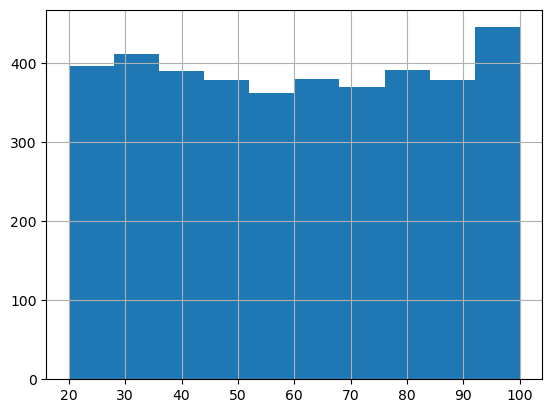

In [27]:
import matplotlib.pyplot as plt

df["Purchase Amount (USD)"].hist()
plt.show()

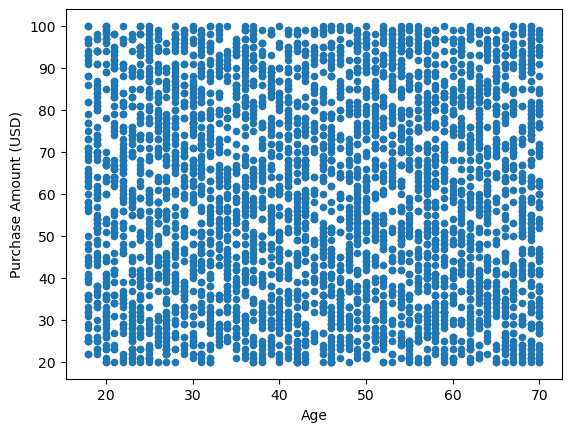

In [28]:
df.plot.scatter(
    x="Age",
    y="Purchase Amount (USD)"
)

plt.show()

In [33]:
df["Age Group"] = pd.cut(
    df["Age"],
    bins=[17, 29, 44, 59, 70],
    labels=["Genç", "Orta yaş", "İleri yaş", "60+"]
)

C:\Users\esmah\AppData\Local\Temp\ipykernel_19344\4169178804.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Age Group")["Purchase Amount (USD)"].mean().plot(kind="bar")


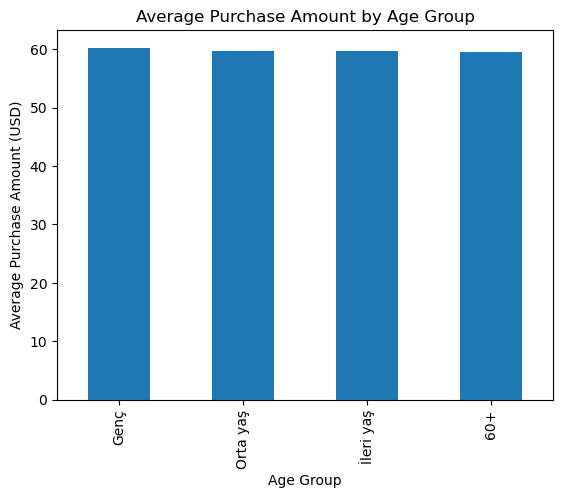

In [34]:
import matplotlib.pyplot as plt
df.groupby("Age Group")["Purchase Amount (USD)"].mean().plot(kind="bar")

plt.ylabel("Average Purchase Amount (USD)")
plt.xlabel("Age Group")
plt.title("Average Purchase Amount by Age Group")
plt.show()
%matplotlib inline

In [35]:
df["Purchase Amount (USD)"].describe()

count    3900.000000
mean       59.764359
std        23.685392
min        20.000000
25%        39.000000
50%        60.000000
75%        81.000000
max       100.000000
Name: Purchase Amount (USD), dtype: float64

outlier = aykırı değer var mı ? bunu gösterir

In [37]:
Q1 = df["Purchase Amount (USD)"].quantile(0.25)
Q3 = df["Purchase Amount (USD)"].quantile(0.75)
IQR = Q3 - Q1
print(IQR)

42.0


In [39]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound)
print(upper_bound)

-24.0
144.0


In [40]:
outliers = df[
    (df["Purchase Amount (USD)"] < lower_bound) |
    (df["Purchase Amount (USD)"] > upper_bound)
]

print(outliers)

Empty DataFrame
Columns: [Customer ID, Age, Gender, Item Purchased, Category, Purchase Amount (USD), Age Group]
Index: []


IQR'nin amacı doğrudan uç değerleri temizlemek değil; uç değerleri tespit etmek/belirlemek için kullanılan bir yöntemdir.

In [41]:
df[["Age", "Purchase Amount (USD)"]].corr()

,Age,Purchase Amount (USD)
Age,1.000000,-0.010424
Purchase Amount (USD),-0.010424,1.000000


In [42]:
df.groupby("Category")["Purchase Amount (USD)"].sum()

Category
Accessories     74200
Clothing       104264
Footwear        36093
Outerwear       18524
Name: Purchase Amount (USD), dtype: int64

mean() → bir alışverişte ortalama ne kadar harcanıyor?
sum() → kategorinin toplam satış tutarı ne kadar?

In [43]:
query = """
CREATE TABLE purchases (
    "Customer ID" INTEGER,
    Purchase INTEGER
);
"""

conn.execute(query)
conn.commit()

In [44]:
query = """
INSERT INTO purchases ("Customer ID", Purchase)
VALUES
(1, 500),
(2, 700),
(3, 300);
"""

conn.execute(query)
conn.commit()

In [45]:
query = """
SELECT *
FROM customers
JOIN purchases
ON customers."Customer ID" = purchases."Customer ID";
"""

result = pd.read_sql_query(query, conn)
print(result)

   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
0            1   55   Male         Blouse  Clothing                     53   
1            2   19   Male        Sweater  Clothing                     64   
2            3   50   Male          Jeans  Clothing                     73   

   Customer ID  Purchase  
0            1       500  
1            2       700  
2            3       300  


In [46]:
query = """
SELECT customers."Customer ID",
       customers."Age",
       purchases."Purchase"
FROM customers
JOIN purchases
ON customers."Customer ID" = purchases."Customer ID";
"""

result = pd.read_sql_query(query, conn)
print(result)

   Customer ID  Age  Purchase
0            1   55       500
1            2   19       700
2            3   50       300
